# 02 — Pré-processamento

**Dimensão 4 da rúbrica — 15 pontos.**

Cada decisão precisa de justificativa escrita. Decidir *não* criar features é
aceitável, desde que o motivo esteja explícito.

In [578]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

credit_record = Path("..") / "data" / "raw" / "credit_record.csv" 
application_record = Path("..") / "data" / "raw" / "application_record.csv"

credit_record = pd.read_csv(credit_record)
application_record = pd.read_csv(application_record)

df = pd.merge(credit_record, application_record, on="ID", how="inner")
df.head()
df.to_csv('../data/raw/df.csv', index=False)

RAW = Path("..") / "data" / "raw" / "df.csv"
PROCESSED = Path("..") / "data" / "processed"
TARGET = "COMPLIANCE"

pd.set_option("display.max_columns", None)

## 1. Dados faltantes

In [579]:
# Identificando colunas com valores nulos
df.isnull().sum()

ID                          0
MONTHS_BALANCE              0
STATUS                      0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        240048
CNT_FAM_MEMBERS             0
dtype: int64

----

***Tratando os nulos da coluna OCCUPATION_TYPE***

**Decisão:** 

Baseado no dicionário de dados, se o número na coluna DAYS_EMPLOYED for positivo, significa que a pessoa está desempregada.

Logo, para essa condição, decidimos substituir os nulos da coluna OCCUPATION_TYPE por "Unemployed".

Posteriormente, o restante dos dados nulos na coluna OCCUPATION_TYPE foi substituído por "Unkown", pois esses dados não foram informados.

In [580]:
# Pelo dicionário de dados, se o número na coluna DAYS_EMPLOYED for positivo, significa que a pessoa está desempregada.
# Logo, para essa condição, podemos substituir os nulos da coluna OCCUPATION_TYPE por "Unemployed".

for item in df[df.DAYS_EMPLOYED > 0].index:
  df.loc[item, "OCCUPATION_TYPE"] = "Unemployed"


# Já para o restante dos nulos, podemos substituir por "Unknown", pois não temos informações sobre a ocupação dessas pessoas.
df.fillna('Unknown', inplace=True)

df.OCCUPATION_TYPE.isnull().sum()

np.int64(0)

## 2. Definição da variável alvo

---------
A variável **TARGET/ALVO** será a coluna **COMPLIANCE** que será gerada a partir da análise do **STATUS** do cliente


**Para a análise será ultilizado o seguinte critério:**


Mal Pagador (1)   : clientes que apresentam os indicadores 2, 3, 4 ou 5 em seu STATUS, demonstrando inadimplência grave, com atrasos maiores de 60 dias.

Bom Pagador (0)   : clientes que apresentam os indicadores 0, 1, C ou X.

In [581]:
# Agrupando df por cliente

cliente = df.groupby('ID')['STATUS'].sum().reset_index()
cliente.head()

# Separando o status que identifica ma pagador (>=60 dias de atraso)
bad_status = {'2', '3', '4', '5'}

# Criando de uma coluna chamada COMPLIANCE que será preenchida com 0 ou 1
cliente['COMPLIANCE'] = cliente.STATUS.apply(lambda s: 1 if any(char in bad_status for char in str(s)) else 0)

# Excluindo da coluna STATUS, que não será mais utilizada
cliente.drop(columns='STATUS', inplace=True)

# Juntando os 2 dataframes
df = pd.merge(df, cliente, on='ID', how='inner')
df.head()

,ID,MONTHS_BALANCE,STATUS,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,COMPLIANCE
0,5008804,0,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
1,5008804,-1,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
2,5008804,-2,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
3,5008804,-3,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0
4,5008804,-4,C,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0


In [582]:
df.shape

(777715, 21)

**Excluindo colunas que não serão mais utilizadas**

In [583]:
# Excuindo as colunas MONTHS_BALANCE e STATUS, que não serão mais utilizadas e a coluna FLAG_MOBIL que contém apenas 1 valor
df.drop(columns=['MONTHS_BALANCE', 'STATUS', 'FLAG_MOBIL'], inplace=True)
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,COMPLIANCE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0


In [584]:
# Removendo os valores duplicados
df.drop_duplicates(inplace=True)
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,COMPLIANCE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
16,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,Unknown,2.0,0
31,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,Security staff,2.0,0
61,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0,0
66,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0,0


In [585]:
df.reset_index(inplace=True)

In [586]:
df.shape

(36457, 19)

## 3. Normalização / padronização

**Escolha e justificativa:**

Foi escolhido o **StandardScaler** para as colunas **numéricas**, pois essas colunas apresentam valores bem diferentes.

Aplicando o StandardScaler elas ficam todas com a mesma escala (com média para 0 e desvio padrão para 1)

----

**Tratando a coluna DAYS_EMPLOYED**

Antes de aplicar o escalonador, há necessidade de tratar os valores da coluna DAYS_EMPLOYED.

Pelo histograma da etapa 1.2, verifica-se que há valores positivos bem discrepantes e que o range maior é para os positivos. 

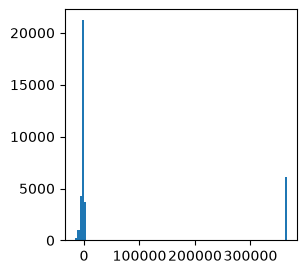

In [587]:
fig = plt.subplots(figsize=(3, 3))
plt.hist(data=df, x='DAYS_EMPLOYED', bins=100)
plt.show()

In [588]:
# Verificando os valores únicos positivos
df.DAYS_EMPLOYED[df.DAYS_EMPLOYED > 0].unique()

array([365243])

Verifica-se que há apenas 1 valor positivo (365243) para vários clientes (indicando que o cliente está desempregado) o que pode se tratar que é uma espécie de flag.

Alterando os valores positivos da coluna DAYS_EMPLOYED para 1, para não afetar os testes.

In [589]:
# Tratando os valores positivos da coluna DAYS_EMPLOYED
df.DAYS_EMPLOYED = df.DAYS_EMPLOYED.apply(lambda x: 1 if x > 0 else x)
df.DAYS_EMPLOYED[df.DAYS_EMPLOYED > 0].unique()

array([1])

----

Aplicando o **StandardScaler** nas vaiáveis numéricas de interesse**

In [590]:
# Aplicando o StandardScaler nas variáveis numéricas "AMT_INCOME_TOTAL", "DAYS_BIRTH", "DAYS_EMPLOYED", "CNT_CHILDREN" e "CNT_FAM_MEMBERS"

# Separando as colunas numéricas
numericas = ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

# Instanciando o escalonador
scaler = StandardScaler()

# Escalonando
df_scaled = scaler.fit_transform(df[numericas])

# Transformando em dataframe
df_scaled = pd.DataFrame(df_scaled, columns=numericas)

df.shape

(36457, 19)

In [591]:
# Excluindo as colunas numéricas do df original
df.drop(columns=df[numericas], inplace = True)

df.columns

Index(['index', 'ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'OCCUPATION_TYPE', 'COMPLIANCE'],
      dtype='str')

In [592]:
df_scaled

,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS
0,2.365845,0.945169,-0.989408,-0.579661,-0.217680
1,2.365845,0.945169,-0.989408,-0.579661,-0.217680
2,-0.728827,-1.309091,0.450437,-0.579661,-0.217680
3,0.818509,-0.746300,-0.359476,-0.579661,-1.314564
4,0.818509,-0.746300,-0.359476,-0.579661,-1.314564
...,...,...,...,...,...
36452,-0.286731,1.230135,0.194831,0.767400,0.879204
36453,-0.286731,1.230135,0.194831,0.767400,0.879204
36454,-0.286731,1.230135,0.194831,0.767400,0.879204
36455,-0.286731,1.230135,0.194831,0.767400,0.879204


In [593]:
# Juntando os dataframes
df = pd.concat([df, df_scaled], axis = 1)
df.shape

(36457, 19)

## 4. Feature engineering

**Justificativa:**

Há colunas que podem ser binarizadas e as colunas categóricas podem ser tratadas para ficarem com o mesmo padrão das outras colunas.

Para isso, foram escolhidos o **Label Encoder** e o **One-Hot Encoder**.

_____

**Verificando as colunas que podem ser binarizadas**

In [594]:
# Verificando os valores únicos de cada coluna
for col in df.columns:
  if df[col].nunique() == 2:
    print(f"Coluna: {col}, Valores únicos: {df[col].unique()}")

Coluna: CODE_GENDER, Valores únicos: <StringArray>
['M', 'F']
Length: 2, dtype: str
Coluna: FLAG_OWN_CAR, Valores únicos: <StringArray>
['Y', 'N']
Length: 2, dtype: str
Coluna: FLAG_OWN_REALTY, Valores únicos: <StringArray>
['Y', 'N']
Length: 2, dtype: str
Coluna: FLAG_WORK_PHONE, Valores únicos: [1 0]
Coluna: FLAG_PHONE, Valores únicos: [0 1]
Coluna: FLAG_EMAIL, Valores únicos: [0 1]
Coluna: COMPLIANCE, Valores únicos: [0 1]


As colunas CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_WORK_PHONE, FLAG_PHONE, e FLAG_EMAIL possuem apenas 2 valores, porém apenas 3 delas (CODE_GENDER, FLAG_OWN_CAR, FLAG_OWN_REALTY) não são binarizadas.

Para binarizá-las, será utilizado o **Label Encoder**.

In [595]:
# Separando as colunas
colunas = ['CODE_GENDER','FLAG_OWN_CAR','FLAG_OWN_REALTY']

# Aplicando o label_encorder
label_encoder = LabelEncoder()
for i in colunas:
  df[i] = label_encoder.fit_transform(df[i])
df.head()

# Legenda: M = 1, F = 0, Y = 1, N = 0

,index,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,COMPLIANCE,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS
0,0,5008804,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,2.365845,0.945169,-0.989408,-0.579661,-0.217680
1,16,5008805,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,2.365845,0.945169,-0.989408,-0.579661,-0.217680
2,31,5008806,1,1,1,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,0,-0.728827,-1.309091,0.450437,-0.579661,-0.217680
3,61,5008808,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0.818509,-0.746300,-0.359476,-0.579661,-1.314564
4,66,5008809,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0.818509,-0.746300,-0.359476,-0.579661,-1.314564


In [596]:
df.shape

(36457, 19)

----

**Aplicando o One-Hot Encoder nas colunas categóricas**

In [597]:
# Separando as colunas categóricas
categoricas = []

for i in df.columns:
  if df[i].dtype == 'str':
    categoricas.append(i)


# Aplicando o hot encoder
hot = []

for i in df.columns:
  hot = pd.get_dummies(df[categoricas], prefix = 'hot')


# Mesclando os  dataframes
df = pd.concat([df, hot], axis=1)
df.head()

,index,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,COMPLIANCE,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_CHILDREN,CNT_FAM_MEMBERS,hot_Commercial associate,hot_Pensioner,hot_State servant,hot_Student,hot_Working,hot_Academic degree,hot_Higher education,hot_Incomplete higher,hot_Lower secondary,hot_Secondary / secondary special,hot_Civil marriage,hot_Married,hot_Separated,hot_Single / not married,hot_Widow,hot_Co-op apartment,hot_House / apartment,hot_Municipal apartment,hot_Office apartment,hot_Rented apartment,hot_With parents,hot_Accountants,hot_Cleaning staff,hot_Cooking staff,hot_Core staff,hot_Drivers,hot_HR staff,hot_High skill tech staff,hot_IT staff,hot_Laborers,hot_Low-skill Laborers,hot_Managers,hot_Medicine staff,hot_Private service staff,hot_Realty agents,hot_Sales staff,hot_Secretaries,hot_Security staff,hot_Unemployed,hot_Unknown,hot_Waiters/barmen staff
0,0,5008804,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,2.365845,0.945169,-0.989408,-0.579661,-0.217680,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,16,5008805,1,1,1,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,0,2.365845,0.945169,-0.989408,-0.579661,-0.217680,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,31,5008806,1,1,1,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,0,-0.728827,-1.309091,0.450437,-0.579661,-0.217680,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,61,5008808,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0.818509,-0.746300,-0.359476,-0.579661,-1.314564,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,66,5008809,0,0,1,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,0,0.818509,-0.746300,-0.359476,-0.579661,-1.314564,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [598]:
df.drop(columns=['index', 'ID'], inplace=True)

In [599]:
df.shape

(36457, 58)

## 5. Salvar dataset tratado

In [600]:
dataset_tratado = df.copy

PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED / "dataset_tratado.csv", index=False)